<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # upload FruitinAmazon.zip

with zipfile.ZipFile('FruitinAmazon.zip', 'r') as z:
    z.extractall('.')

# Handle nested folder
base = 'FruitinAmazon'
if 'FruitinAmazon' in os.listdir(base):
    base = 'FruitinAmazon/FruitinAmazon'

train_dir = os.path.join(base, 'train')
test_dir  = os.path.join(base, 'test')

print("Train classes:", os.listdir(train_dir))
print("Test classes :", os.listdir(test_dir))

Saving FruitinAmazon.zip to FruitinAmazon.zip
Train classes: ['graviola', 'cupuacu', 'tucuma', 'pupunha', 'acai', 'guarana']
Test classes : ['graviola', 'cupuacu', 'tucuma', 'pupunha', 'acai', 'guarana']


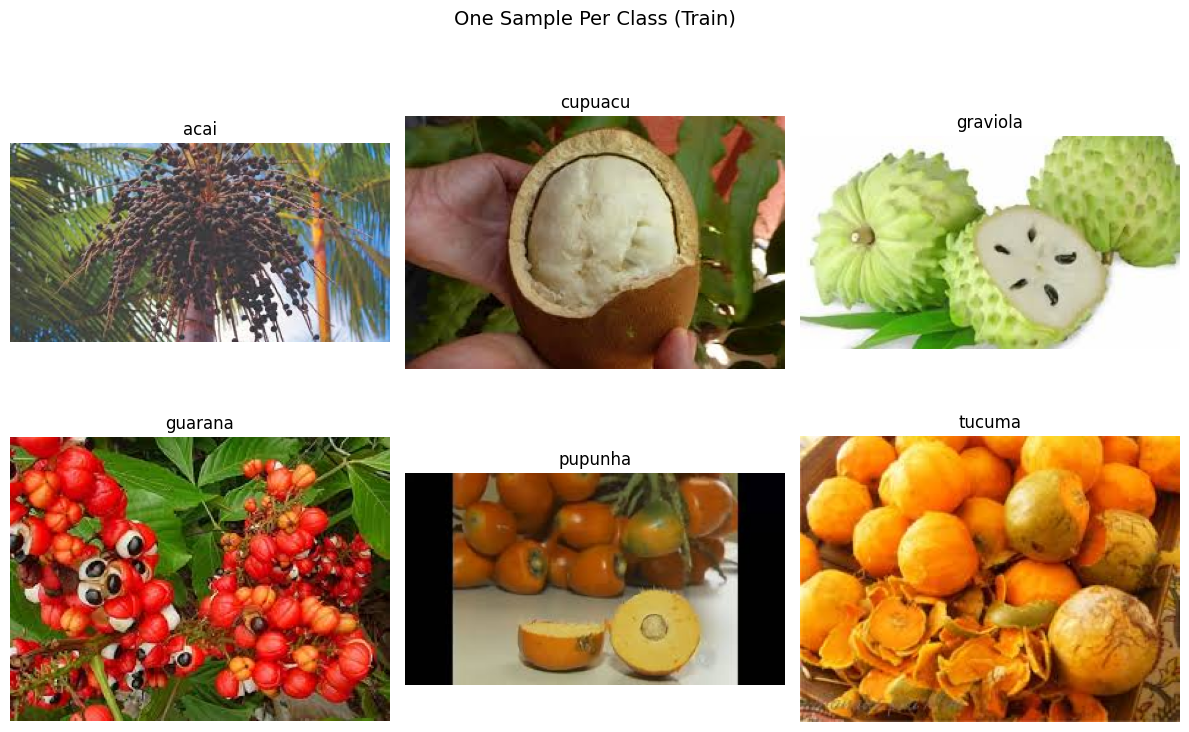

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image

class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

cols = 3
rows = max(2, (len(class_dirs) + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, class_name in enumerate(class_dirs):
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not images:
        continue
    img = Image.open(os.path.join(class_path, random.choice(images)))
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("One Sample Per Class (Train)", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
from PIL import Image
import os

corrupted = []

for split_dir in [train_dir, test_dir]:
    for class_name in os.listdir(split_dir):
        class_path = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
            except (IOError, SyntaxError):
                print(f"Removed corrupted image: {img_path}")
                os.remove(img_path)
                corrupted.append(img_path)

if not corrupted:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [8]:
import tensorflow as tf

img_height       = 128
img_width        = 128
batch_size       = 4
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# ✅ Grab class_names BEFORE .map()
class_names = train_ds_raw.class_names
num_classes  = len(class_names)

# Now apply rescaling
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds_raw.map(lambda x, y: (rescale(x), y))

print("Classes    :", class_names)
print("Num classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes    : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6


In [10]:
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# ✅ Grab BEFORE .map()
test_class_names = test_ds_raw.class_names

test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

print("Test classes:", test_class_names)

Found 30 files belonging to 6 classes.
Test classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint(
    'best_model.h5',
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.2236 - loss: 2.4824
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.2083 - loss: 2.1155 - val_accuracy: 0.0000e+00 - val_loss: 1.8082
Epoch 2/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.4234 - loss: 1.7067
Epoch 2: val_accuracy improved from 0.00000 to 0.44444, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.4028 - loss: 1.6584 - val_accuracy: 0.4444 - val_loss: 1.5105
Epoch 3/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5226 - loss: 1.3260
Epoch 3: val_accuracy did not improve from 0.44444
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.5417 - loss: 1.2401 - val_accuracy: 0.4444 - val_loss: 1.3757
Epoch 4/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7720 - loss: 0.7870
Epoch 4: val_accuracy improved from 0.44444 to 0.77778, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.7639 - loss: 0.7632 - val_accuracy: 0.7778 - val_loss: 0.3845
Epoch 5/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9751 - loss: 0.3237
Epoch 5: val_accuracy improved from 0.77778 to 0.94444, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.9444 - loss: 0.3842 - val_accuracy: 0.9444 - val_loss: 0.2359
Epoch 6/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9733 - loss: 0.1483
Epoch 6: val_accuracy did not improve from 0.94444
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.9583 - loss: 0.1643 - val_accuracy: 0.8333 - val_loss: 0.4085
Epoch 7/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9946 - loss: 0.0685
Epoch 7: val_accuracy did not improve from 0.94444
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9861 - loss: 0.0857 - val_accuracy: 0.8889 - val_loss: 0.7383
Epoch 8/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9811 - loss: 0.1263
Epoch 8: val_accuracy did not improve from 0.94444
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.9722 - loss: 0.1189 - val_accuracy: 0.8333 - val_loss: 0.8441
Epoch 9/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.95

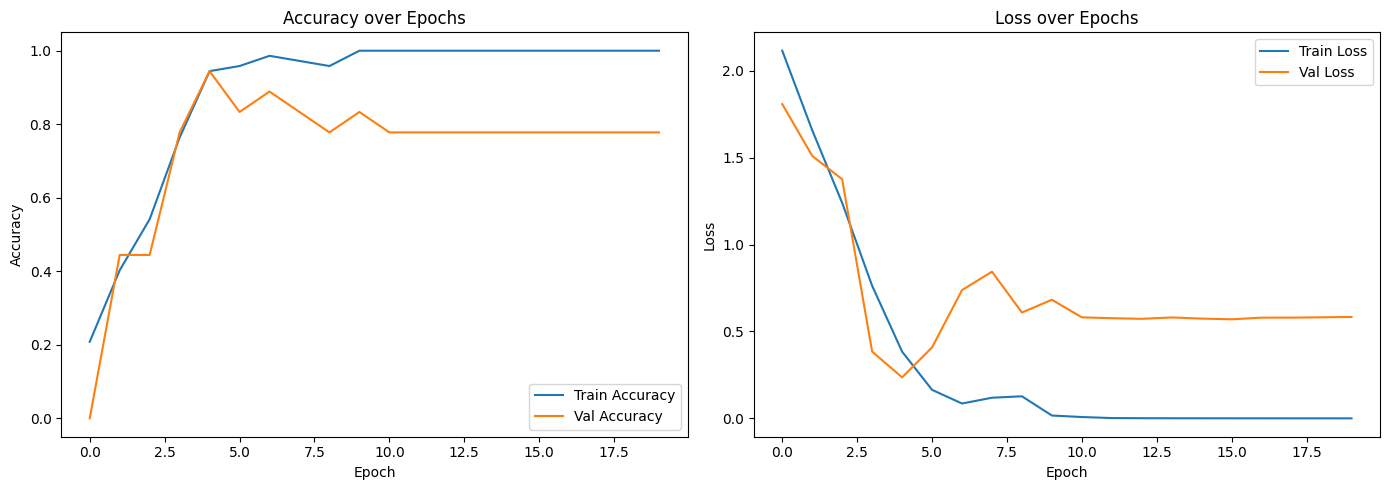

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# ✅ Evaluate on val_ds (same 2 classes as train)
# test_ds has 6 classes so model.evaluate on it will error — use val instead
val_loss, val_acc = model.evaluate(val_ds)
print(f"\nVal Loss    : {val_loss:.4f}")
print(f"Val Accuracy: {val_acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9444 - loss: 0.2359

Val Loss    : 0.2359
Val Accuracy: 0.9444


In [16]:
model.save('fruit_cnn_model.h5')
print("Model saved.")

from tensorflow.keras.models import load_model

loaded_model = load_model('fruit_cnn_model.h5')
loss, acc = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model — Val Loss: {loss:.4f} | Val Accuracy: {acc:.4f}")

Model saved.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9444 - loss: 0.2359

Loaded Model — Val Loss: 0.2359 | Val Accuracy: 0.9444


In [18]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ✅ Get only the labels that actually appear in y_true
unique_labels = sorted(np.unique(y_true))
actual_class_names = [class_names[i] for i in unique_labels]

print(classification_report(
    y_true,
    y_pred,
    labels=unique_labels,           # ✅ only evaluate these label indices
    target_names=actual_class_names, # ✅ matched to unique_labels
    zero_division=0
))

              precision    recall  f1-score   support

     pupunha       1.00      0.67      0.80         3
      tucuma       0.94      1.00      0.97        15

    accuracy                           0.94        18
   macro avg       0.97      0.83      0.88        18
weighted avg       0.95      0.94      0.94        18



In [19]:
from google.colab import files
files.download('fruit_cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>